<a href="https://colab.research.google.com/github/waleedahmed0253/CICMalDroid/blob/main/CICMalDroidCode.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#1.Environment Set Up

##1.1 Installing Libraires

In [1]:
#!pip install pandas scikit-learn numpy matplotlib -U gdown

##1.2 Importing Libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from collections import Counter
import pprint
from datetime import date
from IPython.display import display
from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.ensemble import RandomForestClassifier, VotingClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, confusion_matrix,
    classification_report, ConfusionMatrixDisplay, roc_curve,
    auc, precision_recall_curve, precision_recall_fscore_support
)
from scipy.stats import ttest_rel, wilcoxon
import joblib
import gdown
from sklearn.ensemble import RandomForestClassifier, VotingClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

print("Environment setup complete — all libraries impoted successfully")


Environment setup complete — all libraries impoted successfully


#2.Dataset Loading & Exploration

##2.1 Data Loading

In [3]:
file_id = '1CUNdHFe_dzqAK-jAeW0l6JRJZZMrDrHO'
gdown.download(f'https://drive.google.com/uc?id={file_id}', 'CICMalDroidDataset.csv', quiet=False)

df = pd.read_csv('CICMalDroidDataset.csv')

Downloading...
From: https://drive.google.com/uc?id=1CUNdHFe_dzqAK-jAeW0l6JRJZZMrDrHO
To: /content/CICMalDroidDataset.csv
100%|██████████| 11.7M/11.7M [00:00<00:00, 34.5MB/s]


##2.2 Dataset Dimensions

In [4]:
print("(Rows, Columns):", df.shape)

(Rows, Columns): (11598, 471)


##2.3 Column Names

In [5]:
print(df.columns.tolist())

['ACCESS_PERSONAL_INFO___', 'ALTER_PHONE_STATE___', 'ANTI_DEBUG_____', 'CREATE_FOLDER_____', 'CREATE_PROCESS`_____', 'CREATE_THREAD_____', 'DEVICE_ACCESS_____', 'EXECUTE_____', 'FS_ACCESS____', 'FS_ACCESS()____', 'FS_ACCESS(CREATE)____', 'FS_ACCESS(CREATE__APPEND)__', 'FS_ACCESS(CREATE__READ)__', 'FS_ACCESS(CREATE__READ__WRITE)', 'FS_ACCESS(CREATE__WRITE)__', 'FS_ACCESS(CREATE__WRITE__APPEND)', 'FS_ACCESS(READ)____', 'FS_ACCESS(READ__WRITE)__', 'FS_ACCESS(WRITE)____', 'FS_PIPE_ACCESS___', 'FS_PIPE_ACCESS()___', 'FS_PIPE_ACCESS(READ)___', 'FS_PIPE_ACCESS(READ__)_', 'FS_PIPE_ACCESS(READ__WRITE)_', 'FS_PIPE_ACCESS(WRITE)___', 'NETWORK_ACCESS____', 'NETWORK_ACCESS()____', 'NETWORK_ACCESS(READ)____', 'NETWORK_ACCESS(READ__WRITE)__', 'NETWORK_ACCESS(READ__WRITE__)', 'NETWORK_ACCESS(WRITE)____', 'NETWORK_ACCESS(WRITE__)__', 'SMS_SEND____', 'TERMINATE_PROCESS', 'TERMINATE_THREAD', '__arm_nr_cacheflush', '__arm_nr_set_tls', '_llseek', '_newselect', 'accept', 'access', 'add', 'addAccessibilityIn

##2.4 Columns Datatype

In [6]:
column_dtypes = df.dtypes.to_frame(name='DataType')
column_dtypes.reset_index(inplace=True)
column_dtypes.columns = ['Column', 'DataType']
display(column_dtypes)

,Column,DataType
0,ACCESS_PERSONAL_INFO___,int64
1,ALTER_PHONE_STATE___,int64
2,ANTI_DEBUG_____,int64
3,CREATE_FOLDER_____,int64
4,CREATE_PROCESS`_____,int64
...,...,...
466,watchRotation,int64
467,windowGainedFocus,int64
468,write,int64
469,writev,int64


##2.5 Dataset Structure

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11598 entries, 0 to 11597
Columns: 471 entries, ACCESS_PERSONAL_INFO___ to Class
dtypes: int64(471)
memory usage: 41.7 MB


##2.6 First 5 Rows of Dataset

In [8]:
display(df.head())

,ACCESS_PERSONAL_INFO___,ALTER_PHONE_STATE___,ANTI_DEBUG_____,CREATE_FOLDER_____,CREATE_PROCESS`_____,CREATE_THREAD_____,DEVICE_ACCESS_____,EXECUTE_____,FS_ACCESS____,FS_ACCESS()____,...,utimes,vfork,vibrate,vibratePattern,wait4,watchRotation,windowGainedFocus,write,writev,Class
0,1,0,0,3,0,14,2,0,3,0,...,0,0,0,0,0,0,0,37,10,1
1,3,0,0,6,0,42,91,0,32,0,...,0,0,0,0,0,0,2,2838,46,1
2,2,0,0,4,0,23,3,0,17,2,...,0,0,0,0,0,0,1,111,20,1
3,1,0,0,4,0,27,9,0,36,0,...,0,0,0,0,0,0,7,987,197,1
4,3,0,0,11,0,18,3,0,16,0,...,0,0,0,0,0,0,1,98,25,1


##2.6 Last 5 Rows of Dataset

In [9]:
display(df.tail())

,ACCESS_PERSONAL_INFO___,ALTER_PHONE_STATE___,ANTI_DEBUG_____,CREATE_FOLDER_____,CREATE_PROCESS`_____,CREATE_THREAD_____,DEVICE_ACCESS_____,EXECUTE_____,FS_ACCESS____,FS_ACCESS()____,...,utimes,vfork,vibrate,vibratePattern,wait4,watchRotation,windowGainedFocus,write,writev,Class
11593,2,0,0,11,0,61,13,0,66,17,...,0,0,0,0,0,0,10,2764,236,5
11594,6,0,0,10,1,69,50,1,118,15,...,0,0,0,0,1,0,5,4417,295,5
11595,0,0,0,0,0,21,16,0,48,9,...,0,0,0,0,0,0,5,241,67,5
11596,1,0,0,15,0,90,80,0,239,50,...,0,0,0,0,0,0,3,1703,774,5
11597,0,0,0,10,0,47,6,0,44,11,...,0,0,0,0,0,0,13,3102,186,5


#3.Exploratory Data Analysis (EDA) Summary Statistics

In [10]:
pd.set_option('display.max_columns', None)
summary_stats = df.describe()
summary_stats

,ACCESS_PERSONAL_INFO___,ALTER_PHONE_STATE___,ANTI_DEBUG_____,CREATE_FOLDER_____,CREATE_PROCESS`_____,CREATE_THREAD_____,DEVICE_ACCESS_____,EXECUTE_____,FS_ACCESS____,FS_ACCESS()____,FS_ACCESS(CREATE)____,FS_ACCESS(CREATE__APPEND)__,FS_ACCESS(CREATE__READ)__,FS_ACCESS(CREATE__READ__WRITE),FS_ACCESS(CREATE__WRITE)__,FS_ACCESS(CREATE__WRITE__APPEND),FS_ACCESS(READ)____,FS_ACCESS(READ__WRITE)__,FS_ACCESS(WRITE)____,FS_PIPE_ACCESS___,FS_PIPE_ACCESS()___,FS_PIPE_ACCESS(READ)___,FS_PIPE_ACCESS(READ__)_,FS_PIPE_ACCESS(READ__WRITE)_,FS_PIPE_ACCESS(WRITE)___,NETWORK_ACCESS____,NETWORK_ACCESS()____,NETWORK_ACCESS(READ)____,NETWORK_ACCESS(READ__WRITE)__,NETWORK_ACCESS(READ__WRITE__),NETWORK_ACCESS(WRITE)____,NETWORK_ACCESS(WRITE__)__,SMS_SEND____,TERMINATE_PROCESS,TERMINATE_THREAD,__arm_nr_cacheflush,__arm_nr_set_tls,_llseek,_newselect,accept,access,add,addAccessibilityInteractionConnection,addAccountExplicitly,addClient,addPeriodicSync,addStatusChangeListener,addToDisplay,addToDisplayWithoutInputChannel,addWithoutInputChannel,attachEngine,beginRestoreSession,bind,brk,cancelAllNotifications,cancelNotificationWithTag,cancelSync,cancelToast,cancelVibrate,capset,chdir,checkOperation,checkPackage,checkPermission,checkSignatures,chmod,chown32,clock_getres,clock_gettime,clone,close,collapsePanels,connect,currentToCanonicalPackageNames,dataChanged,deleteHost,disconnect,displayCompletions,dup,dup2,endRestoreSession,engineShown,enqueueNotificationWithTag,enqueueToast,epoll_create,epoll_ctl,epoll_wait,eventfd2,execve,exit,exit_group,faccessat,fchmod,fchown32,fcntl,fcntl64,fdatasync,finishDrawing,finishInput,finishSpellCheckerService,flock,fork,fstat64,fstatfs64,fsync,ftruncate,ftruncate64,futex,geocoderIsPresent,getAccounts,getAccountsAsUser,getActiveAdmins,getActiveNetworkInfo,getActivePhoneType,getActivityInfo,getAllCellInfo,getAllNetworkInfo,getAllPkgUsageStats,getAllProviders,getAnimationScale,getAppWidgetIds,getAppWidgetInfo,getApplicationEnabledSetting,getApplicationInfo,getApplicationRestrictions,getAuthenticatorTypes,getBestProvider,getBoolean,getCallState,getCameraDisabled,getCameraInfo,getCellLocation,getClientDefaultLanguage,getComponentEnabledSetting,getConfiguredNetworks,getConnectionInfo,getCurrentInputMethodSubtype,getCurrentModeType,getCurrentSpellChecker,getCurrentSpellCheckerSubtype,getDataActivity,getDataNetworkType,getDataState,getDeviceId,getDeviceList,getDeviceOwner,getDeviceSvn,getDhcpInfo,getDisplayFrame,getDisplayIds,getDisplayInfo,getEnabledAccessibilityServiceList,getEnabledInputMethodList,getEnabledInputMethodSubtypeList,getFlashlightEnabled,getFromLocation,getGlobalSearchActivity,getGroupIdLevel1,getHeightHint,getIccSerialNumber,getInTouchMode,getInputDevice,getInputDeviceIds,getInputMethodList,getInstallLocation,getInstalledApplications,getInstalledPackages,getInstalledProviders,getInstallerPackageName,getIsSyncable,getLastChosenActivity,getLastInputMethodSubtype,getLastLocation,getLine1Number,getLong,getMasterSyncAutomatically,getMessenger,getMobileDataEnabled,getMobileIfaces,getMode,getNameForUid,getNeighboringCellInfo,getNetworkInfo,getNetworkPreference,getNightMode,getNumberOfCameras,getPackageGids,getPackageInfo,getPackageSizeInfo,getPackagesForUid,getPassword,getPermissionGroupInfo,getPermissionInfo,getPreferredActivities,getPreferredPackages,getPrimaryClip,getProviderInfo,getProviderProperties,getProviders,getProxy,getReceiverInfo,getRingerMode,getRingtonePlayer,getScanResults,getSearchableInfo,getSearchablesInGlobalSearch,getServiceInfo,getSpellCheckerService,getState,getStorageEncryptionStatus,getStreamMaxVolume,getStreamVolume,getString,getSubscriberId,getSyncAutomatically,getSystemAvailableFeatures,getSystemSharedLibraryNames,getTetheredIfaces,getUserData,getUserIcon,getUserRestrictions,getUserSerialNumber,getUsers,getVibrateSetting,getVoiceMailAlphaTag,getVoiceMailNumber,getWallpaper,getWallpaperInfo,getWidthHint,getWifiApConfiguration,getWifiApEnabledState,getWifiDisplayStatus,getWifiEnabledState,getWifiS

#4.Data Visualizations

##4.1 Class Distribution Plot

,Class,Count,Malware_Type
0,1,1253,Adware
1,2,2100,Banking Malware
2,3,3904,SMS Malware
3,4,2546,Riskware
4,5,1795,Benign


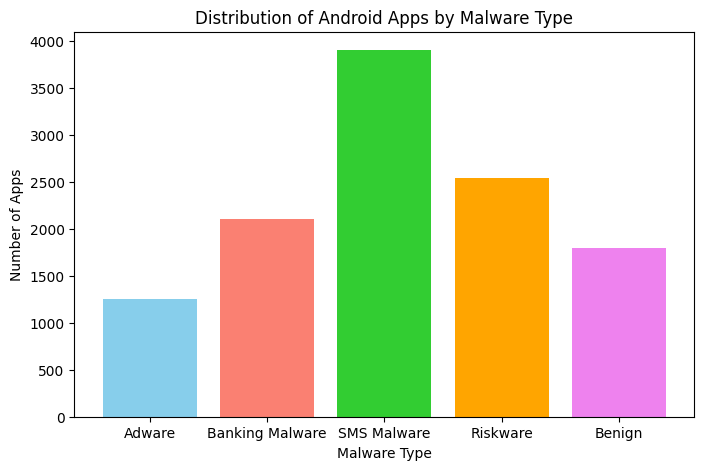

In [11]:
class_mapping = {
    1: 'Adware',
    2: 'Banking Malware',
    3: 'SMS Malware',
    4: 'Riskware',
    5: 'Benign'
}

counts = df['Class'].value_counts().sort_index()

table_df = pd.DataFrame({
    'Class': counts.index,
    'Count': counts.values,
    'Malware_Type': [class_mapping[i] for i in counts.index]
})

display(table_df)

colors = ['skyblue', 'salmon', 'limegreen', 'orange', 'violet']
plt.figure(figsize=(8,5))
plt.bar(table_df['Malware_Type'], table_df['Count'], color=colors)
plt.title('Distribution of Android Apps by Malware Type')
plt.xlabel('Malware Type')
plt.ylabel('Number of Apps')
plt.show()


##4.2 Correlation Heatmap (Top 20 Most Variable Features)

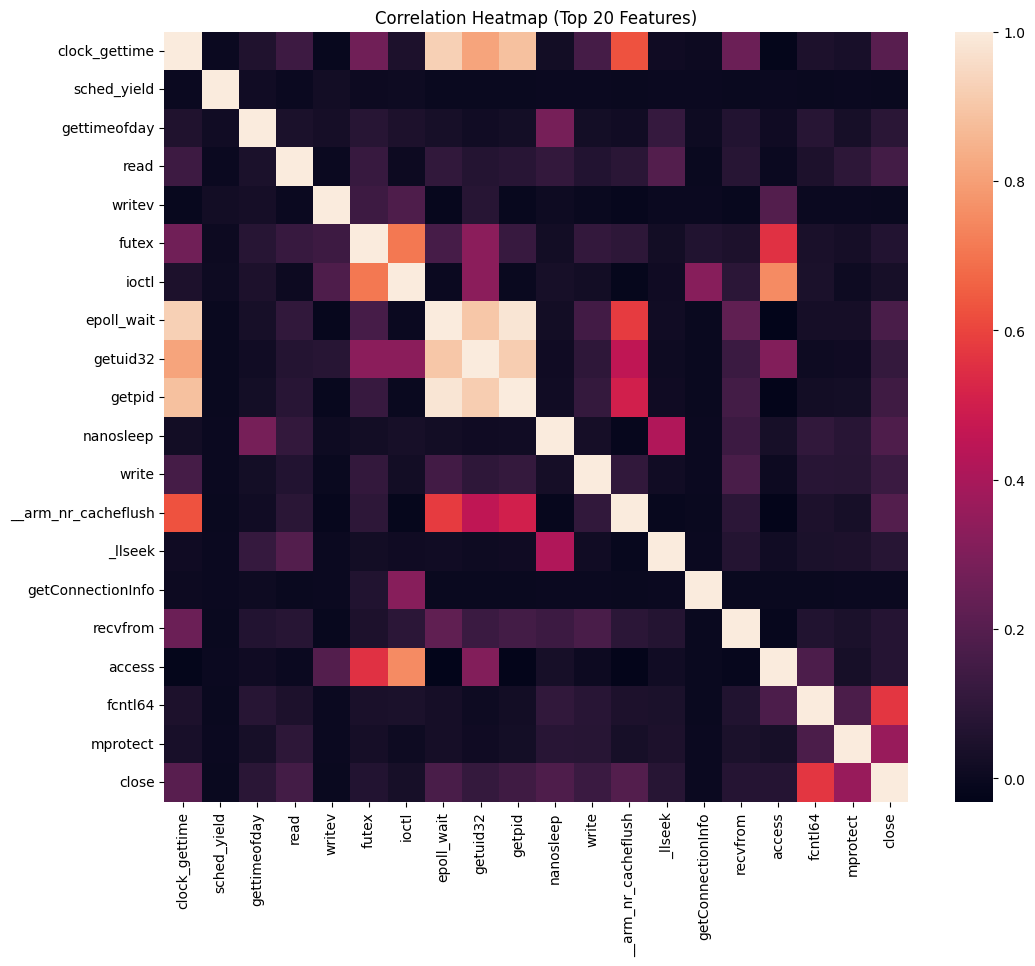

,clock_gettime,sched_yield,gettimeofday,read,writev,futex,ioctl,epoll_wait,getuid32,getpid,nanosleep,write,__arm_nr_cacheflush,_llseek,getConnectionInfo,recvfrom,access,fcntl64,mprotect,close
clock_gettime,1.000000,-0.001750,0.056168,0.136424,-0.007177,0.264002,0.048705,0.925669,0.812863,0.885857,0.019374,0.157452,0.626645,0.013076,0.002123,0.251614,-0.021004,0.046072,0.037492,0.204149
sched_yield,-0.001750,1.000000,0.016269,-0.002418,0.017430,0.001759,0.005916,-0.004414,-0.004190,-0.003672,-0.000741,-0.001911,-0.003737,-0.000989,-0.000403,-0.003349,-0.001720,-0.003110,-0.001915,-0.003923
gettimeofday,0.056168,0.016269,1.000000,0.043560,0.028556,0.075157,0.046169,0.030801,0.016467,0.021801,0.279716,0.021783,0.015180,0.115411,0.006579,0.062634,0.011137,0.075013,0.031588,0.082139
read,0.136424,-0.002418,0.043560,1.000000,-0.000623,0.121341,0.003195,0.103174,0.066162,0.078112,0.107522,0.065001,0.084140,0.191505,-0.003206,0.074226,0.000102,0.046634,0.092530,0.153877
writev,-0.007177,0.017430,0.028556,-0.000623,1.000000,0.135314,0.181832,-0.012849,0.074538,-0.010748,0.007748,-0.004491,-0.012101,0.000711,-0.001304,-0.010160,0.192848,-0.002775,-0.001069,-0.005064
futex,0.264002,0.001759,0.075157,0.121341,0.135314,1.000000,0.706300,0.158856,0.328184,0.118519,0.020657,0.107992,0.090658,0.017432,0.058192,0.045984,0.555728,0.038643,0.029360,0.064886
ioctl,0.048705,0.005916,0.046169,0.003195,0.181832,0.706300,1.000000,0.000183,0.327953,-0.003299,0.031480,0.018214,-0.017091,0.010476,0.319793,0.089290,0.753378,0.042784,0.007755,0.032572
epoll_wait,0.925669,-0.004414,0.030801,0.103174,-0.012849,0.158856,0.000183,1.000000,0.900120,0.982426,0.021338,0.147119,0.579185,0.013553,-0.006535,0.223371,-0.030966,0.027752,0.026068,0.166969
getuid32,0.812863,-0.004190,0.016467,0.066162,0.074538,0.328184,0.327953,0.900120,1.000000,0.918972,0.011145,0.097539,0.456241,0.006024,-0.006671,0.129616,0.309707,0.006802,0.010824,0.113097
getpid,0.885857,-0.003672,0.021801,0.078112,-0.010748,0.118519,-0.003299,0.982426,0.918972,1.000000,0.013710,0.110869,0.504491,0.010127,-0.005591,0.153611,-0.025396,0.020596,0.024395,0.139975


In [12]:
top20 = df.var().sort_values(ascending=False).head(20).index
plt.figure(figsize=(12,10))
sns.heatmap(df[top20].corr(), annot=False)
plt.title('Correlation Heatmap (Top 20 Features)')
plt.show()
display(df[top20].corr())

##4.3 Top 20 Most Frequent API/System Call Features

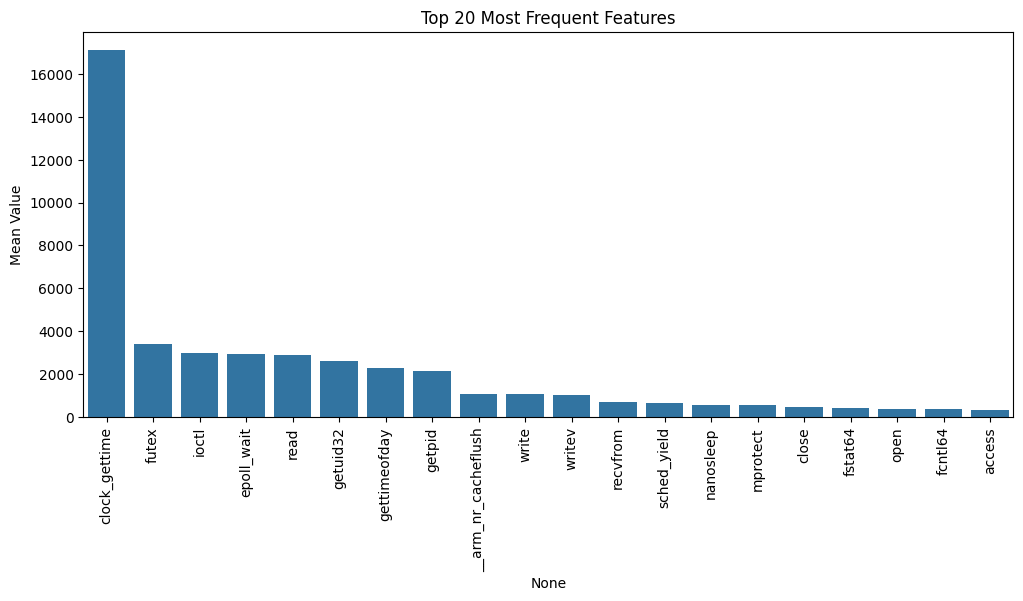

,Feature,Mean Value
0,clock_gettime,17103.524573
1,futex,3403.121659
2,ioctl,3003.004915
3,epoll_wait,2959.879290
4,read,2882.256165
5,getuid32,2630.008277
6,gettimeofday,2297.242283
7,getpid,2151.317727
8,__arm_nr_cacheflush,1083.033885
9,write,1071.197362


In [13]:
freq = df.drop('Class', axis=1).mean().sort_values(ascending=False).head(20)
plt.figure(figsize=(12,5))
sns.barplot(x=freq.index, y=freq.values)
plt.xticks(rotation=90)
plt.title('Top 20 Most Frequent Features')
plt.ylabel('Mean Value')
plt.show()
display(pd.DataFrame(freq).reset_index().rename(columns={'index':'Feature', 0:'Mean Value'}))

##4.4 Boxplot for Selected Key Features

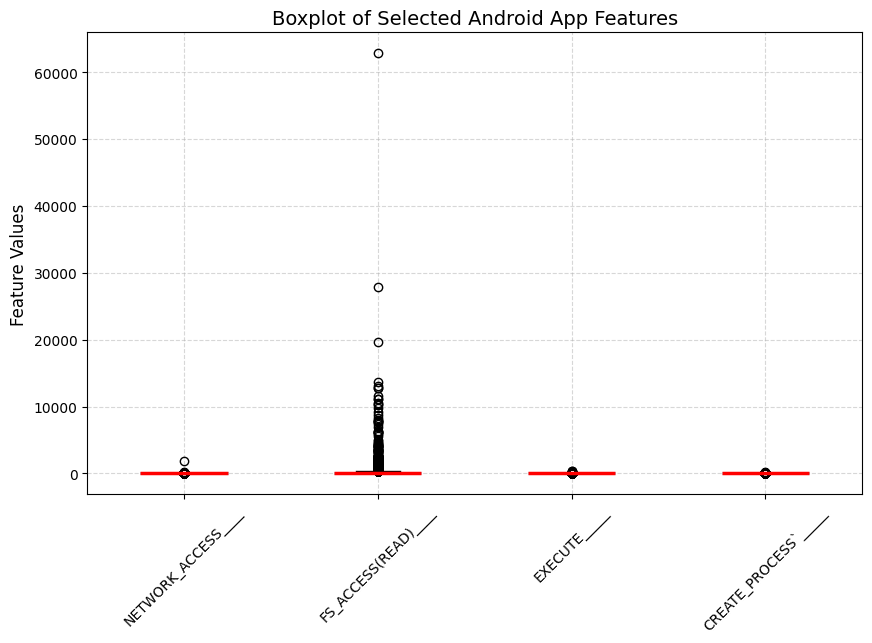

,NETWORK_ACCESS____,FS_ACCESS(READ)____,EXECUTE_____,CREATE_PROCESS`_____
count,11598.000000,11598.000000,11598.00000,11598.000000
mean,5.401621,229.651319,2.25125,0.983877
std,19.466439,886.719497,9.86903,4.061886
min,0.000000,0.000000,0.00000,0.000000
25%,0.000000,10.000000,0.00000,0.000000
50%,0.000000,18.000000,0.00000,0.000000
75%,10.000000,123.000000,0.00000,0.000000
max,1832.000000,62791.000000,399.00000,140.000000


In [14]:
features = ['NETWORK_ACCESS____', 'FS_ACCESS(READ)____', 'EXECUTE_____', 'CREATE_PROCESS`_____']

plt.figure(figsize=(10,6))
boxprops = dict(linestyle='-', linewidth=2, color='skyblue')
medianprops = dict(linestyle='-', linewidth=2.5, color='red')
df[features].boxplot(boxprops=boxprops, medianprops=medianprops, patch_artist=True)
plt.title('Boxplot of Selected Android App Features', fontsize=14)
plt.ylabel('Feature Values', fontsize=12)
plt.xticks(rotation=45, fontsize=10)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

display(df[features].describe())


##4.5 PCA 2D Scatter

,PC1,PC2,Class,Malware_Type
0,-18118.969267,-820.995197,1,Adware
1,18945.259542,-567.374851,1,Adware
2,-17677.878334,-817.280386,1,Adware
3,-8003.808021,-763.833679,1,Adware
4,-17826.590342,-817.704195,1,Adware
5,-18206.738305,-824.160111,1,Adware
6,-18122.290463,-822.392107,1,Adware
7,-17377.469283,-794.690330,1,Adware
8,-18224.499666,-824.295593,1,Adware
9,-16838.844080,-815.165614,1,Adware


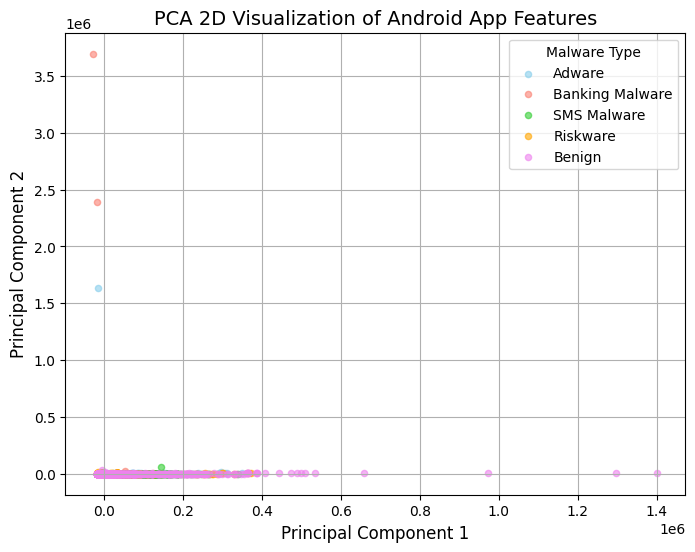

In [15]:
class_mapping = {
    1: 'Adware',
    2: 'Banking Malware',
    3: 'SMS Malware',
    4: 'Riskware',
    5: 'Benign'
}

X = df.select_dtypes(include=['int64', 'float64']).drop('Class', axis=1)
y = df['Class']

pca = PCA(n_components=2)
p = pca.fit_transform(X)

pca_df = pd.DataFrame(p, columns=['PC1','PC2'])
pca_df['Class'] = y
pca_df['Malware_Type'] = pca_df['Class'].map(class_mapping)

colors = {
    'Adware':'skyblue',
    'Banking Malware':'salmon',
    'SMS Malware':'limegreen',
    'Riskware':'orange',
    'Benign':'violet'
}

display(pca_df.head(10))

plt.figure(figsize=(8,6))
for malware_type, color in colors.items():
    subset = pca_df[pca_df['Malware_Type'] == malware_type]
    plt.scatter(subset['PC1'], subset['PC2'], s=20, alpha=0.6, c=color, label=malware_type)

plt.title('PCA 2D Visualization of Android App Features', fontsize=14)
plt.xlabel('Principal Component 1', fontsize=12)
plt.ylabel('Principal Component 2', fontsize=12)
plt.legend(title='Malware Type')
plt.grid(True)
plt.show()


##4.6 Feature Distribution

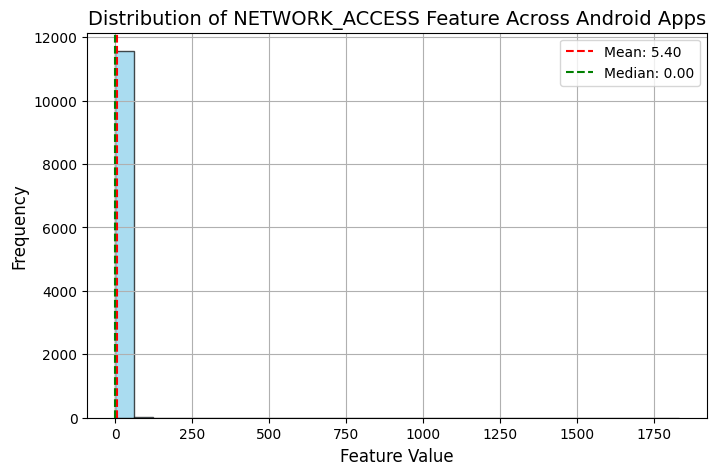

,NETWORK_ACCESS____
count,11598.000000
mean,5.401621
std,19.466439
min,0.000000
25%,0.000000
50%,0.000000
75%,10.000000
max,1832.000000


In [16]:
feature = 'NETWORK_ACCESS____'

plt.figure(figsize=(8,5))
plt.hist(df[feature], bins=30, color='skyblue', edgecolor='black', alpha=0.7)
plt.axvline(df[feature].mean(), color='red', linestyle='dashed', linewidth=1.5, label=f"Mean: {df[feature].mean():.2f}")
plt.axvline(df[feature].median(), color='green', linestyle='dashed', linewidth=1.5, label=f"Median: {df[feature].median():.2f}")
plt.title('Distribution of NETWORK_ACCESS Feature Across Android Apps', fontsize=14)
plt.xlabel('Feature Value', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.legend()
plt.grid(True)
plt.show()

display(df[feature].describe())


#5.Data Pre-processing

##5.1 Check for Missing Values

In [17]:
missing_values = df.isnull().sum()
missing_values = missing_values[missing_values > 0]

if not missing_values.empty:
    print("Missing Values Found:")
    print(missing_values)
else:
    print("No missing values found in the dataset.")

No missing values found in the dataset.


##5.2 Check for Duplicate Records

             Type  Count
0  Duplicate Rows     72
1     Unique Rows  11526


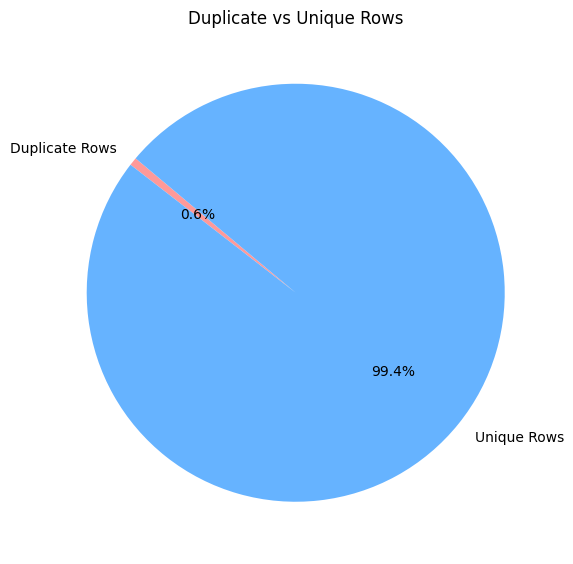

In [18]:
total_duplicates = df.duplicated().sum()
non_duplicates = len(df) - total_duplicates
duplicate_table = pd.DataFrame({
    'Type': ['Duplicate Rows', 'Unique Rows'],
    'Count': [total_duplicates, non_duplicates]
})
print(duplicate_table)

plt.figure(figsize=(6, 6))
plt.pie([total_duplicates, non_duplicates],
        labels=['Duplicate Rows', 'Unique Rows'],
        autopct='%1.1f%%',
        colors=['#ff9999', '#66b3ff'],
        startangle=140)
plt.title("Duplicate vs Unique Rows")
plt.tight_layout()
plt.show()

##5.3 Remove Duplicate Records

In [19]:
df = df.drop_duplicates()

total_duplicates_after = df.duplicated().sum()
non_duplicates_after = len(df) - total_duplicates_after

duplicate_table_after = pd.DataFrame({
    'Type': ['Duplicate Rows', 'Unique Rows'],
    'Count': [total_duplicates_after, non_duplicates_after]
})
print("\nAfter removing duplicates:")
print(duplicate_table_after)


After removing duplicates:
             Type  Count
0  Duplicate Rows      0
1     Unique Rows  11526


#6.Feature Engineering

In [20]:
df['Total_FS_Access'] = df[[col for col in df.columns if 'FS_ACCESS' in col]].sum(axis=1)
df['Total_Network_Access'] = df[[col for col in df.columns if 'NETWORK_ACCESS' in col]].sum(axis=1)
df['Total_Process_Thread'] = df[['CREATE_PROCESS`_____', 'CREATE_THREAD_____', 'TERMINATE_PROCESS', 'TERMINATE_THREAD']].sum(axis=1)
df['Total_SMS_Personal'] = df[['SMS_SEND____', 'ACCESS_PERSONAL_INFO___']].sum(axis=1)
df['Average_FS_Access'] = df[[col for col in df.columns if 'FS_ACCESS' in col]].mean(axis=1)
df['Max_Network_Operation'] = df[[col for col in df.columns if 'NETWORK_ACCESS' in col]].max(axis=1)
df['High_Risk_Actions_Flag'] = df[['EXECUTE_____', 'DEVICE_ACCESS_____', 'ANTI_DEBUG_____']].sum(axis=1).apply(lambda x: 1 if x>0 else 0)
df['FS_vs_Network_Ratio'] = df['Total_FS_Access'] / (df['Total_Network_Access'] + 1)
df['Process_Thread_Intensity'] = df['Total_Process_Thread']
df['Overall_Activity_Score'] = df.drop('Class', axis=1).sum(axis=1)

new_columns = ['Total_FS_Access', 'Total_Network_Access', 'Total_Process_Thread', 'Total_SMS_Personal',
               'Average_FS_Access', 'Max_Network_Operation', 'High_Risk_Actions_Flag',
               'FS_vs_Network_Ratio', 'Process_Thread_Intensity', 'Overall_Activity_Score']

display(df[new_columns].head())

,Total_FS_Access,Total_Network_Access,Total_Process_Thread,Total_SMS_Personal,Average_FS_Access,Max_Network_Operation,High_Risk_Actions_Flag,FS_vs_Network_Ratio,Process_Thread_Intensity,Overall_Activity_Score
0,26,7,17,1,2.363636,4,1,3.250000,17,1426.613636
1,210,35,48,3,19.090909,19,1,5.833333,48,74568.924242
2,55,14,35,2,5.000000,10,1,3.666667,35,3687.666667
3,73,3,39,1,6.636364,2,1,18.250000,39,25296.886364
4,57,19,25,3,5.181818,7,1,2.850000,25,3087.031818


#7.Encoding Target Variable

In [21]:
df['Class'] = df['Class'].map({1:0, 2:1, 3:2, 4:3, 5:4})
df['Class'].value_counts().sort_index()

,count
Class,
0,1253
1,2044
2,3903
3,2534
4,1792


#8.Data Splitting: Training, Validation and Test

In [22]:
X = df.drop('Class', axis=1)
y = df['Class']

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=42
)

In [23]:
print("Training set:", X_train.shape, y_train.shape)
print("Validation set:", X_val.shape, y_val.shape)
print("Test set:", X_test.shape, y_test.shape)

Training set: (8068, 480) (8068,)
Validation set: (1729, 480) (1729,)
Test set: (1729, 480) (1729,)



Malware ratio in each set:
Train: 2.1359692612791275
Validation: 2.136495083863505
Test: 2.1359167148640834 



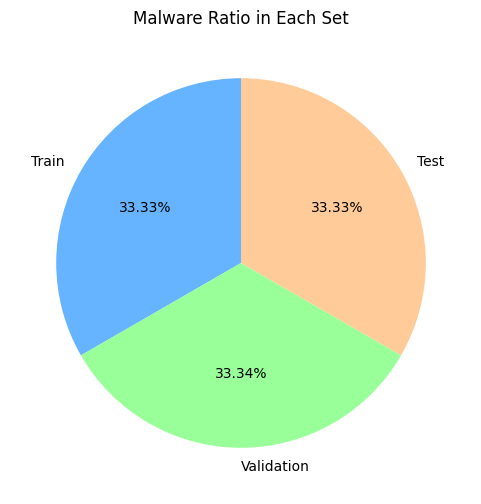

In [24]:
X = df.drop('Class', axis=1)
y = df['Class']

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=42
)

print("\nMalware ratio in each set:")
print("Train:", y_train.mean())
print("Validation:", y_val.mean())
print("Test:", y_test.mean(), "\n")

malware_ratios = {
    "Train": y_train.mean(),
    "Validation": y_val.mean(),
    "Test": y_test.mean()
}

labels = malware_ratios.keys()
sizes = [v * 100 for v in malware_ratios.values()]

plt.figure(figsize=(6,6))
plt.pie(sizes, labels=labels, autopct="%1.2f%%", startangle=90, colors=["#66b3ff","#99ff99","#ffcc99"])
plt.title("Malware Ratio in Each Set")
plt.show()


#9.Data Imbalance

##9.1 Inspect Class Distribution (Before SMOTE)

In [25]:
print("Class distribution in training set (Before SMOTE):\n")
display(y_train.value_counts().sort_index())

Class distribution in training set (Before SMOTE):



,count
Class,
0,877
1,1431
2,2732
3,1774
4,1254


##9.2 Applying SMOTE on Training Set

In [26]:
X_train_res, y_train_res = SMOTE(random_state=42).fit_resample(X_train, y_train)
print("Class distribution in training set (After SMOTE):\n")
display(pd.Series(y_train_res).value_counts().sort_index())

Class distribution in training set (After SMOTE):



,count
Class,
0,2732
1,2732
2,2732
3,2732
4,2732


##9.3 Visulaizing the Class Distribution Before & After SMOTE

/tmp/ipython-input-1754456477.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=[class_mapping[i] for i in before_smote.index], y=before_smote.values, palette='Blues_d')
/tmp/ipython-input-1754456477.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=[class_mapping[i] for i in after_smote.keys()], y=list(after_smote.values()), palette='Greens_d')


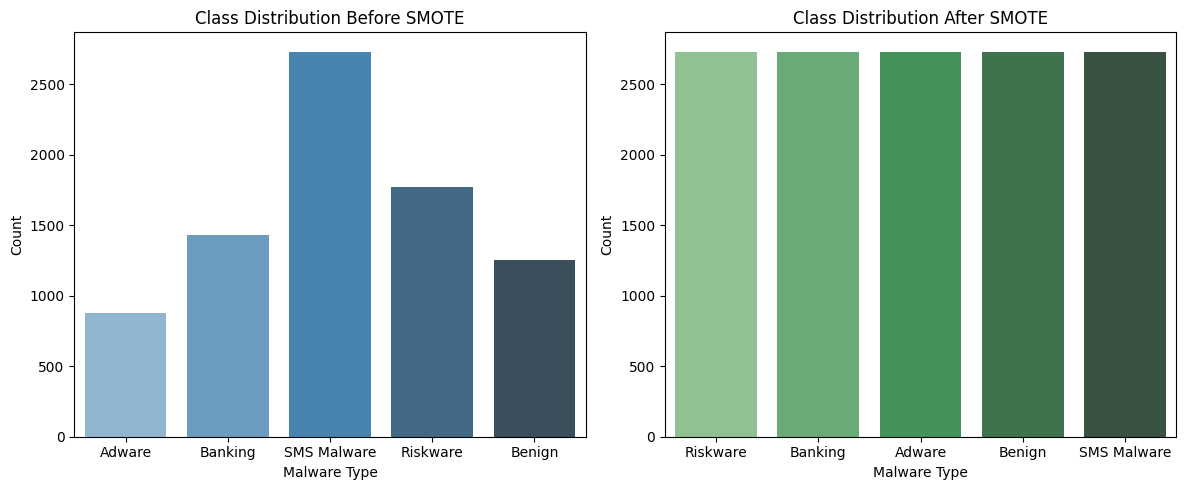

In [27]:
before_smote = y_train.value_counts().sort_index()
after_smote = Counter(y_train_res)

class_mapping = {0: 'Adware', 1: 'Banking', 2: 'SMS Malware', 3: 'Riskware', 4: 'Benign'}

plt.figure(figsize=(12,5))

plt.subplot(1, 2, 1)
sns.barplot(x=[class_mapping[i] for i in before_smote.index], y=before_smote.values, palette='Blues_d')
plt.title('Class Distribution Before SMOTE')
plt.xlabel('Malware Type')
plt.ylabel('Count')

plt.subplot(1, 2, 2)
sns.barplot(x=[class_mapping[i] for i in after_smote.keys()], y=list(after_smote.values()), palette='Greens_d')
plt.title('Class Distribution After SMOTE')
plt.xlabel('Malware Type')
plt.ylabel('Count')

plt.tight_layout()
plt.show()


##9.4 Confirm Balanced Distribution in Training Set

In [28]:
print("Final shape of X_train_resampled:", X_train_res.shape)
print("Final shape of y_train_resampled:", y_train_res.shape)

Final shape of X_train_resampled: (13660, 480)
Final shape of y_train_resampled: (13660,)


#10.Feature Selection

##10.1 Extract and Display Feature Importances

In [29]:
lgb_model = LGBMClassifier(random_state=42)
lgb_model.fit(X_train_res, y_train_res)

feature_importances = pd.DataFrame({
    "Feature": X_train_res.columns,
    "Importance": lgb_model.feature_importances_
})

feature_importances.sort_values(by="Importance", ascending=False, inplace=True)

importance_threshold = feature_importances["Importance"].mean()
top_features = feature_importances[feature_importances["Importance"] >= importance_threshold]["Feature"]

print("\nNumber of selected Top Features:", len(top_features), "\n")
print(list(top_features))


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.192047 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 22736
[LightGBM] [Info] Number of data points in the train set: 13660, number of used features: 309
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438

Number of selected Top Features: 119 

['mprotect', 'writev', 'sigprocmask', 'brk', 'futex', 'read', 'pread64', 'ioctl', 'gettimeofday', 'getpriority', 'getDisplayInfo', 'recvfrom', 'Overall_Activity_Score', 'clock_gettime', 'write', 'FS_vs_Network_Ratio', 'mkdir', 'munmap', 'FS_ACCESS____', 'getpid', 'access', 'mmap2', 'stat64', 'getPackageInfo', 'epoll_wait', 'getApplicationInfo', 'getuid32', 'CREATE_FOLDER_____', 'madvise', 'prctl'

##10.2 Analysis of Highly Predictive Features

In [30]:
feature_importances = pd.DataFrame({
    "Feature": X_train_res.columns,
    "Importance": lgb_model.feature_importances_
})

feature_importances.sort_values(by="Importance", ascending=False, inplace=True)

threshold = feature_importances["Importance"].mean() + feature_importances["Importance"].std()
very_important_features = feature_importances[feature_importances["Importance"] >= threshold]

In [31]:
print(f"Total number of features considered: {feature_importances.shape[0]}")
print(f"Number of highly predictive features (Importance ≥ mean + 1 std): {len(very_important_features)}\n")
print("These features contribute the most to model predictions and can be considered for further feature selection:\n")
display(very_important_features.reset_index(drop=True))

Total number of features considered: 480
Number of highly predictive features (Importance ≥ mean + 1 std): 49

These features contribute the most to model predictions and can be considered for further feature selection:



,Feature,Importance
0,mprotect,530
1,writev,528
2,sigprocmask,422
3,brk,383
4,futex,310
5,read,296
6,pread64,285
7,ioctl,271
8,gettimeofday,258
9,getpriority,254


/tmp/ipython-input-1330126311.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Importance", y="Feature", data=very_important_features, palette="rocket")


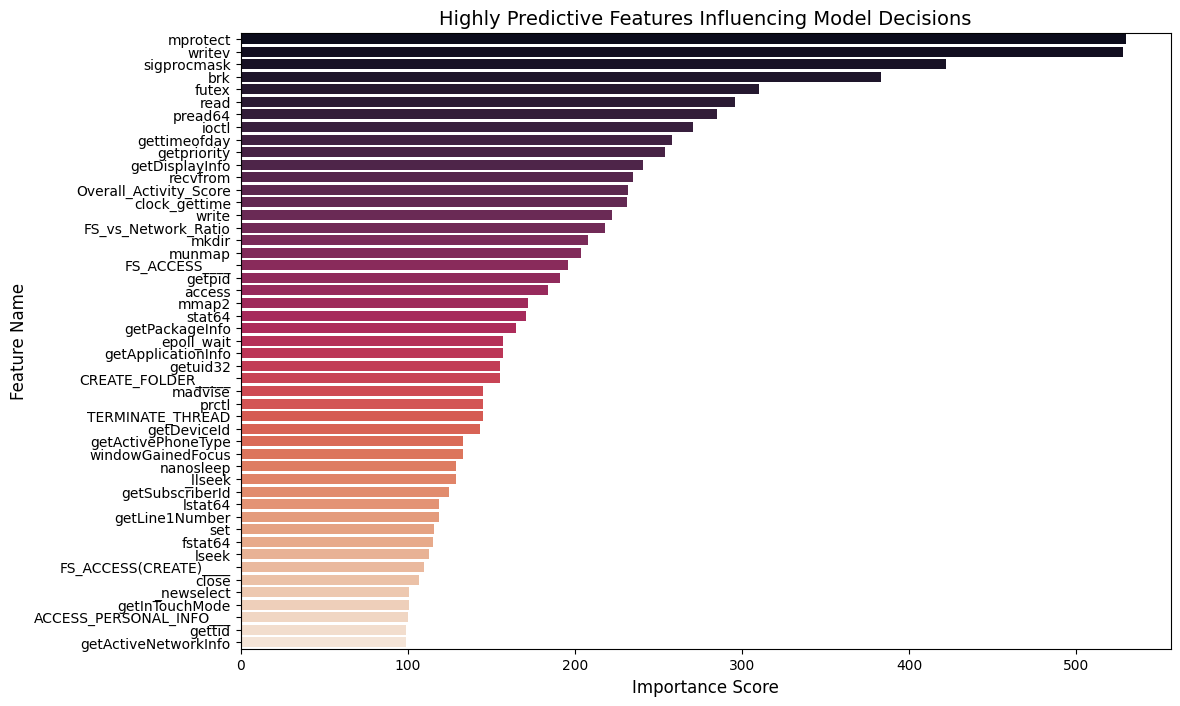

In [32]:
plt.figure(figsize=(12,8))
sns.barplot(x="Importance", y="Feature", data=very_important_features, palette="rocket")
plt.title("Highly Predictive Features Influencing Model Decisions", fontsize=14)
plt.xlabel("Importance Score", fontsize=12)
plt.ylabel("Feature Name", fontsize=12)
plt.show()

##10.3 Selection of Highly Predictive Features

In [33]:
top_features_list = very_important_features["Feature"].tolist()

X_train_top = X_train_res[top_features_list]
X_val_top = X_val[top_features_list]
X_test_top = X_test[top_features_list]

print("Shapes of datasets after selecting highly predictive features:")
print("X_train_top:", X_train_top.shape)
print("X_val_top:", X_val_top.shape)
print("X_test_top:", X_test_top.shape)

Shapes of datasets after selecting highly predictive features:
X_train_top: (13660, 49)
X_val_top: (1729, 49)
X_test_top: (1729, 49)


#11.Model Training and Evaluation

##11.1 Define All Models (Baseline + Advanced + Ensemble)

In [34]:
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier, VotingClassifier, StackingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.neural_network import MLPClassifier

baseline_models = {
    "LogisticRegression": LogisticRegression(
        max_iter=300,
        n_jobs=-1,
        multi_class="auto"
    ),
    "GaussianNB": GaussianNB(),
    "LinearSVM": LinearSVC(
        max_iter=100,
        dual=False,
        random_state=42
    )
}

advanced_models = {
    "RandomForest": RandomForestClassifier(
        n_estimators=120,
        max_depth=20,
        min_samples_split=10,
        min_samples_leaf=5,
        n_jobs=-1,
        random_state=42
    ),
    "XGBoost": XGBClassifier(
        n_estimators=120,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="multi:softprob",
        eval_metric="mlogloss",
        n_jobs=-1,
        random_state=42
    ),
    "LightGBM": LGBMClassifier(
        n_estimators=150,
        max_depth=-1,
        learning_rate=0.1,
        num_leaves=31,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    ),
    "MLP": MLPClassifier(
        hidden_layer_sizes=(128, 64),
        activation="relu",
        solver="adam",
        alpha=0.0005,
        batch_size=256,
        max_iter=120,
        random_state=42
    )
}

ensemble_models = {
    "Voting": VotingClassifier(
        estimators=[
            ("rf", advanced_models["RandomForest"]),
            ("lgbm", advanced_models["LightGBM"]),
            ("mlp", advanced_models["MLP"])
        ],
        voting="soft",
        n_jobs=-1
    ),
    "Stacking": StackingClassifier(
        estimators=[
            ("rf", advanced_models["RandomForest"]),
            ("lgbm", advanced_models["LightGBM"]),
            ("mlp", advanced_models["MLP"])
        ],
        final_estimator=LogisticRegression(max_iter=300),
        n_jobs=-1
    )
}

all_models = {
    "Baseline Models": list(baseline_models.keys()),
    "Advanced Models": list(advanced_models.keys()),
    "Ensemble Models": list(ensemble_models.keys())
}

for category, models in all_models.items():
    print(f"\n{category}:")
    for m in models:
        print("-", m)



Baseline Models:
- LogisticRegression
- GaussianNB
- LinearSVM

Advanced Models:
- RandomForest
- XGBoost
- LightGBM
- MLP

Ensemble Models:
- Voting
- Stacking


##11.2 Model Evaluation Function (Validation Metrics + Confusion Matrix)

In [35]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

def evaluate_model(model, X_train, y_train, X_val, y_val, model_name):
    print(f"\n--- Evaluating Model: {model_name} ---")
    print("Metrics defined for evaluation:")
    print("- Accuracy: overall correctness of predictions")
    print("- Precision (weighted): correctness of positive predictions across all classes")
    print("- Recall (weighted): ability to find all positive instances across all classes")
    print("- F1-score (weighted): harmonic mean of precision and recall")
    print("- Confusion Matrix: detailed class-wise performance\n")

    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)

    if model_name == "XGBoost":
        y_pred = y_pred + 1

    acc = accuracy_score(y_val, y_pred)
    prec = precision_score(y_val, y_pred, average="weighted")
    rec = recall_score(y_val, y_pred, average="weighted")
    f1 = f1_score(y_val, y_pred, average="weighted")

    print(f"Accuracy: {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall: {rec:.4f}")
    print(f"F1-score: {f1:.4f}")

    cm = confusion_matrix(y_val, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap="Blues")
    plt.title(f"Confusion Matrix - {model_name}")
    plt.show()

    return {
        "Model": model_name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1_Score": f1
    }



##11.3 Model Training on Top Features Dataset

In [36]:
trained_models_final = {}

for name, model in {**baseline_models, **advanced_models, **ensemble_models}.items():
    print(f"Training model: {name} ...")

    if name == "XGBoost":
        model.fit(X_train_top, y_train_res)
    else:
        model.fit(X_train_top, y_train_res)

    trained_models_final[name] = model
    print(f"Model {name} trained successfully.\n")

print("All Models Trained on Top Features Dataset")


Training model: LogisticRegression ...


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Model LogisticRegression trained successfully.

Training model: GaussianNB ...
Model GaussianNB trained successfully.

Training model: LinearSVM ...


/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


Model LinearSVM trained successfully.

Training model: RandomForest ...
Model RandomForest trained successfully.

Training model: XGBoost ...
Model XGBoost trained successfully.

Training model: LightGBM ...
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003495 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 10057
[LightGBM] [Info] Number of data points in the train set: 13660, number of used features: 49
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
Model LightGBM trained successfully.

Training model: MLP ...
Model MLP trained successfully.

Training model: Voting ...
Model Voting trained successfully.

Training m

##11.4 Evaluation of Trained Models on Validation Set


In [37]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Evaluation Metrics of Trained Models on Validation Set\n")

all_results = []

for name, model in trained_models_final.items():
    y_val_eval = y_val
    y_pred = model.predict(X_val_top)

    acc = accuracy_score(y_val_eval, y_pred)
    prec = precision_score(y_val_eval, y_pred, average="weighted")
    rec = recall_score(y_val_eval, y_pred, average="weighted")
    f1 = f1_score(y_val_eval, y_pred, average="weighted")

    all_results.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1_Score": f1
    })

results_df = pd.DataFrame(all_results).sort_values(by="F1_Score", ascending=False)
print("Model Comparison on Validation Set")
display(results_df)


Evaluation Metrics of Trained Models on Validation Set

Model Comparison on Validation Set


,Model,Accuracy,Precision,Recall,F1_Score
8,Stacking,0.946212,0.946694,0.946212,0.946301
5,LightGBM,0.945055,0.945596,0.945055,0.945183
4,XGBoost,0.943320,0.944584,0.943320,0.943551
3,RandomForest,0.939271,0.942348,0.939271,0.939811
7,Voting,0.938693,0.942114,0.938693,0.939329
6,MLP,0.742047,0.782661,0.742047,0.738133
1,GaussianNB,0.531521,0.570783,0.531521,0.485664
2,LinearSVM,0.454598,0.617698,0.454598,0.438834
0,LogisticRegression,0.405437,0.578389,0.405437,0.389275


## 11.5 Confusion Matrices of Trained Models on Validation Dataset


Confusion Matrices for Each Model



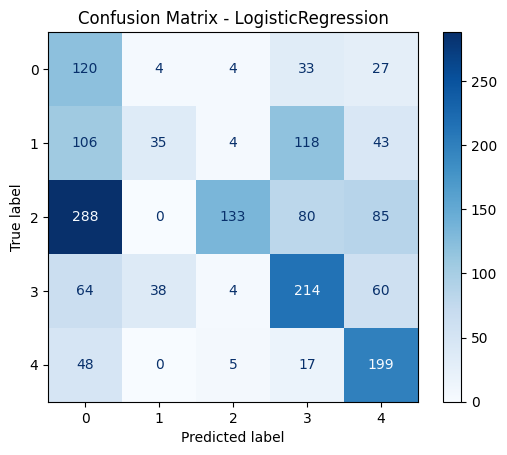

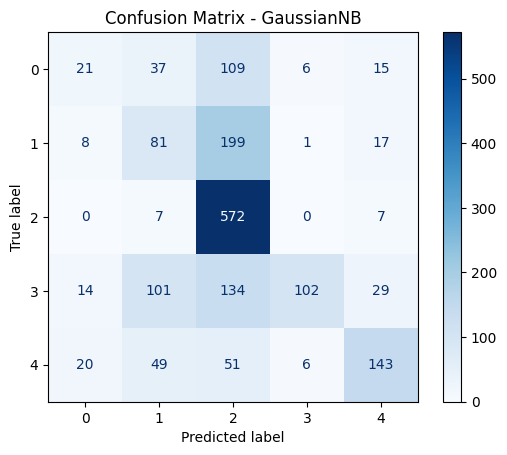

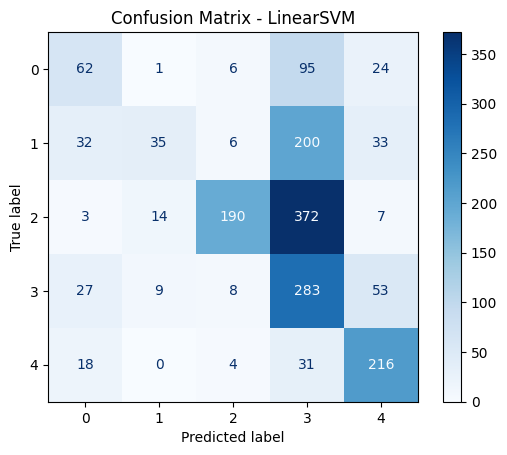

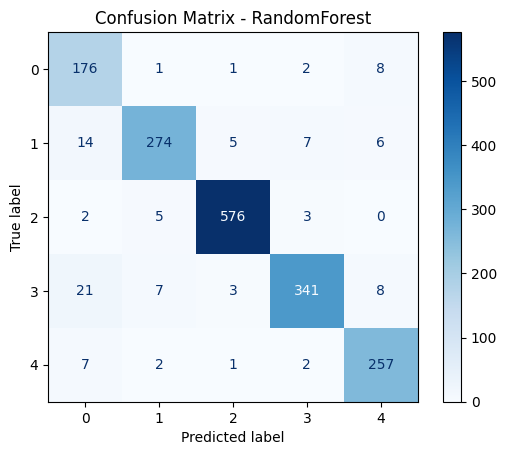

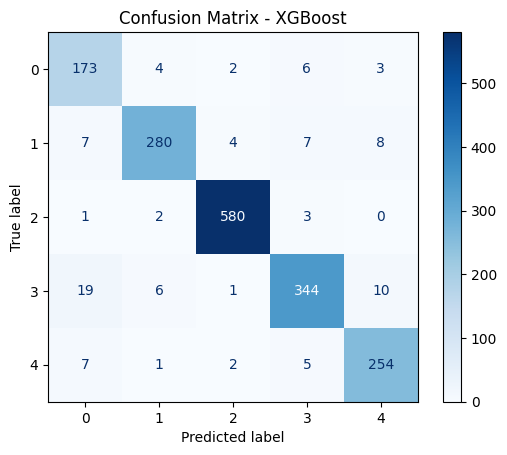

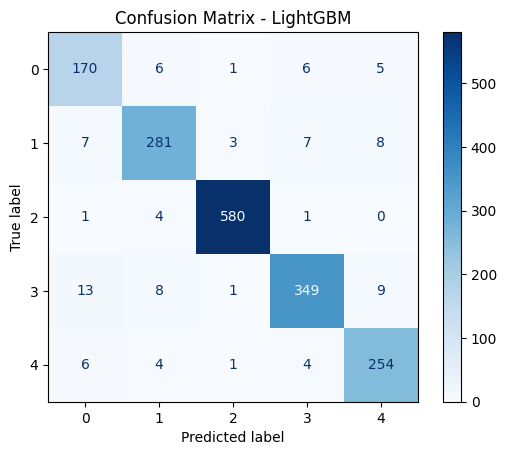

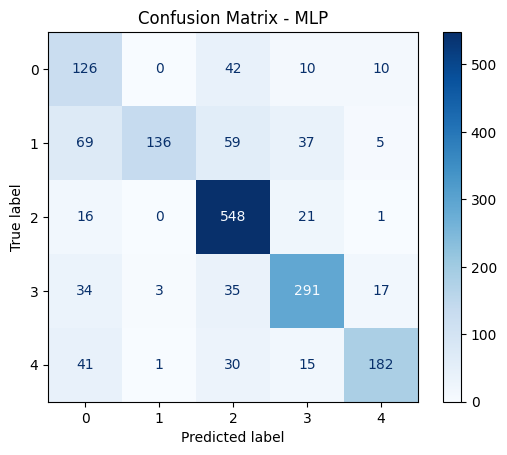

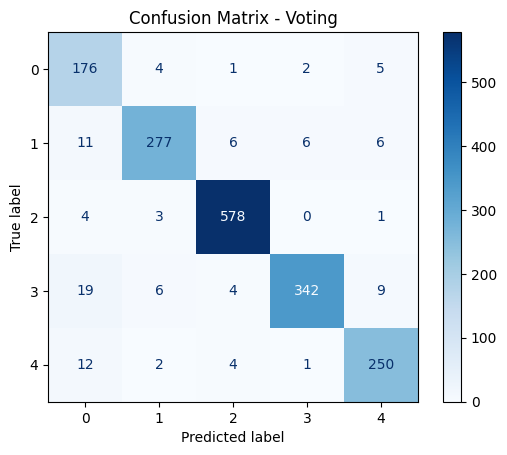

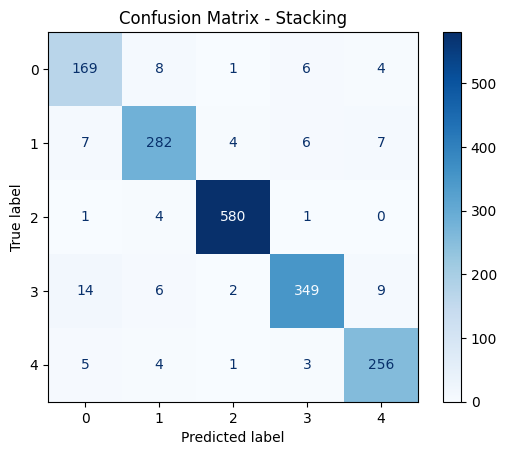

In [38]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

print("Confusion Matrices for Each Model\n")

for name, model in trained_models_final.items():
    y_val_eval = y_val
    y_pred = model.predict(X_val_top)

    cm = confusion_matrix(y_val_eval, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap="Blues")
    plt.title(f"Confusion Matrix - {name}")
    plt.show()


#12.K-Fold Cross-Validation for All Models

##12.1 K-Fold Cross-Validation on Top Features Dataset with Metrics Table

In [39]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Performing 3-Fold Stratified Cross-Validation on Top Features Dataset\n")

kf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
cv_results = []

for name, model in trained_models_final.items():
    acc_list, prec_list, rec_list, f1_list = [], [], [], []

    for train_index, val_index in kf.split(X_train_top, y_train_res):
        X_train_fold, X_val_fold = X_train_top.iloc[train_index], X_train_top.iloc[val_index]
        y_train_fold, y_val_fold = y_train_res.iloc[train_index], y_train_res.iloc[val_index]

        model.fit(X_train_fold, y_train_fold)
        y_pred = model.predict(X_val_fold)

        acc_list.append(accuracy_score(y_val_fold, y_pred))
        prec_list.append(precision_score(y_val_fold, y_pred, average="weighted"))
        rec_list.append(recall_score(y_val_fold, y_pred, average="weighted"))
        f1_list.append(f1_score(y_val_fold, y_pred, average="weighted"))

    cv_results.append({
        "Model": name,
        "Accuracy": np.mean(acc_list),
        "Precision": np.mean(prec_list),
        "Recall": np.mean(rec_list),
        "F1_Score": np.mean(f1_list)
    })

cv_results_df = pd.DataFrame(cv_results).sort_values(by="F1_Score", ascending=False)
print("Cross-Validation Results (Average Metrics Across Folds)")
display(cv_results_df)


Performing 3-Fold Stratified Cross-Validation on Top Features Dataset



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of itera

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.006482 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 9675
[LightGBM] [Info] Number of data points in the train set: 9106, number of used features: 49
[LightGBM] [Info] Start training from score -1.608999
[LightGBM] [Info] Start training from score -1.609548
[LightGBM] [Info] Start training from score -1.609548
[LightGBM] [Info] Start training from score -1.609548
[LightGBM] [Info] Start training from score -1.609548
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004237 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 9663
[LightGBM] [Info] Number of data points in the train set: 9107, number of used features: 49
[LightGBM] [Info] Start training from score -1.609658
[LightGBM] [Info] Start training fro

,Model,Accuracy,Precision,Recall,F1_Score
8,Stacking,0.962226,0.962408,0.962226,0.962199
5,LightGBM,0.961860,0.962145,0.961860,0.961832
4,XGBoost,0.955198,0.955581,0.955198,0.955159
7,Voting,0.949195,0.950545,0.949195,0.949205
3,RandomForest,0.939678,0.940751,0.939678,0.939629
6,MLP,0.602275,0.716170,0.602275,0.585130
0,LogisticRegression,0.466764,0.526542,0.466764,0.434315
2,LinearSVM,0.456660,0.617975,0.456660,0.432625
1,GaussianNB,0.431186,0.539745,0.431186,0.402472


##12.2 Bar Chart Comparison of Model Performance Across Metrics

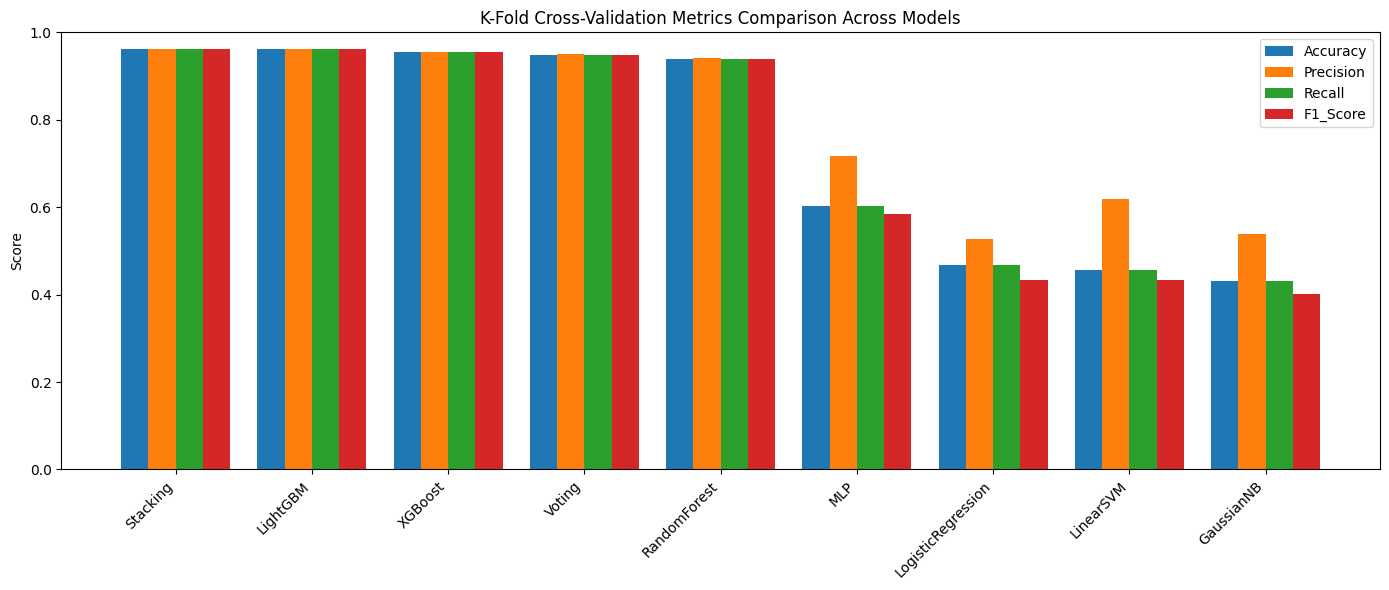

In [40]:
metrics = ["Accuracy", "Precision", "Recall", "F1_Score"]
models = cv_results_df["Model"].tolist()
x = np.arange(len(models))
width = 0.2

plt.figure(figsize=(14,6))

for i, metric in enumerate(metrics):
    plt.bar(x + i*width, cv_results_df[metric], width=width, label=metric)

plt.xticks(x + width*1.5, models, rotation=45, ha="right")
plt.ylabel("Score")
plt.title("K-Fold Cross-Validation Metrics Comparison Across Models")
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()
plt.show()


##12.3 Top 3 Performing Models Based on F1-Score

In [41]:
top_3_models = cv_results_df.sort_values(by="F1_Score", ascending=False).head(3)

print("Top 3 Models Based on Weighted F1-Score\n")
display(top_3_models)

Top 3 Models Based on Weighted F1-Score



,Model,Accuracy,Precision,Recall,F1_Score
8,Stacking,0.962226,0.962408,0.962226,0.962199
5,LightGBM,0.961860,0.962145,0.961860,0.961832
4,XGBoost,0.955198,0.955581,0.955198,0.955159


# 13.Hyperparameter Tuning on the Top 3 Models from K-Fold Cross-Validation

##13.1 Defining Parameter Grids

In [42]:
lgbm_param_grid = {
    "num_leaves": [31, 50],
    "max_depth": [-1, 10],
    "learning_rate": [0.05, 0.1],
    "n_estimators": [50, 100]
}

xgb_param_grid = {
    "max_depth": [3, 6],
    "learning_rate": [0.05, 0.1],
    "n_estimators": [50, 100],
    "subsample": [0.8],
    "colsample_bytree": [0.8]
}

stacking_param_grid = {
    "final_estimator__C": [0.1, 1],
    "final_estimator__solver": ["lbfgs"]
}

##13.2 Initializing Models

In [43]:
from sklearn.ensemble import StackingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

lgbm_model = LGBMClassifier(random_state=42)
xgb_model = XGBClassifier(
    objective="multi:softprob",
    eval_metric="mlogloss",
    n_jobs=-1,
    random_state=42,
    verbosity=0
)

stacking_model = StackingClassifier(
    estimators=[
        ("rf", RandomForestClassifier(n_estimators=120, random_state=42)),
        ("lgbm", LGBMClassifier(n_estimators=150, random_state=42)),
        ("mlp", MLPClassifier(hidden_layer_sizes=(128, 64), max_iter=120, random_state=42))
    ],
    final_estimator=LogisticRegression(max_iter=300),
    n_jobs=-1
)


##13.3 Running Hyperparameter Tuning

In [44]:
from sklearn.model_selection import GridSearchCV

cv_folds = 3

lgbm_grid = GridSearchCV(lgbm_model, lgbm_param_grid, scoring="f1_weighted", cv=cv_folds, n_jobs=-1, verbose=1)
xgb_grid = GridSearchCV(xgb_model, xgb_param_grid, scoring="f1_weighted", cv=cv_folds, n_jobs=-1, verbose=1)
stacking_grid = GridSearchCV(stacking_model, stacking_param_grid, scoring="f1_weighted", cv=cv_folds, n_jobs=-1, verbose=1)

print("Tuning LightGBM...")
lgbm_grid.fit(X_train_top, y_train_res)
print(f"Best LightGBM Params: {lgbm_grid.best_params_}")
print(f"Best LightGBM F1-Score: {lgbm_grid.best_score_:.4f}\n")

print("Tuning XGBoost...")
xgb_grid.fit(X_train_top, y_train_res)
print(f"Best XGBoost Params: {xgb_grid.best_params_}")
print(f"Best XGBoost F1-Score: {xgb_grid.best_score_:.4f}\n")

print("Tuning Stacking...")
stacking_grid.fit(X_train_top, y_train_res)
print(f"Best Stacking Params: {stacking_grid.best_params_}")
print(f"Best Stacking F1-Score: {stacking_grid.best_score_:.4f}\n")


Tuning LightGBM...
Fitting 3 folds for each of 16 candidates, totalling 48 fits
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003512 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 10057
[LightGBM] [Info] Number of data points in the train set: 13660, number of used features: 49
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
Best LightGBM Params: {'learning_rate': 0.1, 'max_depth': -1, 'n_estimators': 100, 'num_leaves': 31}
Best LightGBM F1-Score: 0.9636

Tuning XGBoost...
Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best XGBoost Params: {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 6, 

##13.4 Hyperparameter Tuning Results Summary

In [45]:
tuning_results = pd.DataFrame({
    "Model": ["LightGBM", "XGBoost", "Stacking"],
    "Best Parameters": [
        lgbm_grid.best_params_,
        xgb_grid.best_params_,
        stacking_grid.best_params_
    ],
    "Best F1_Score": [
        round(lgbm_grid.best_score_, 4),
        round(xgb_grid.best_score_, 4),
        round(stacking_grid.best_score_, 4)
    ]
})

print("Summary of Best Hyperparameters and F1-Scores for Tuned Models")
display(tuning_results)


Summary of Best Hyperparameters and F1-Scores for Tuned Models


,Model,Best Parameters,Best F1_Score
0,LightGBM,"{'learning_rate': 0.1, 'max_depth': -1, 'n_est...",0.9636
1,XGBoost,"{'colsample_bytree': 0.8, 'learning_rate': 0.1...",0.9550
2,Stacking,"{'final_estimator__C': 0.1, 'final_estimator__...",0.9659


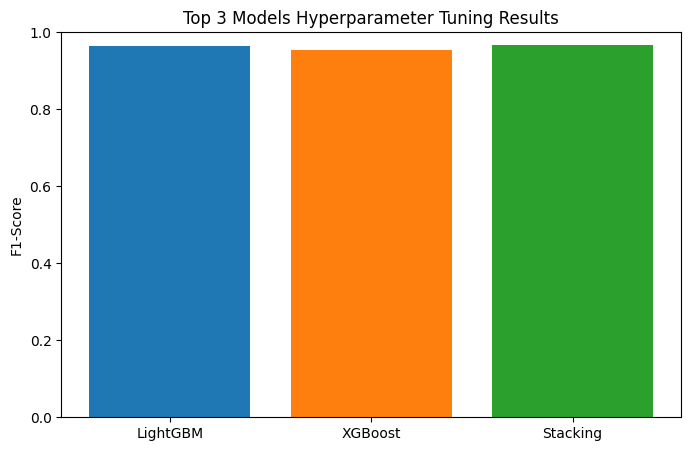

In [46]:
plt.figure(figsize=(8,5))
plt.bar(tuning_results["Model"], tuning_results["Best F1_Score"], color=["#1f77b4", "#ff7f0e", "#2ca02c"])
plt.ylim(0, 1)
plt.ylabel("F1-Score")
plt.title("Top 3 Models Hyperparameter Tuning Results")
plt.show()



#14.Model Performance Comparisons with Statistical Significance

##14.1 Build Best Models After Hyperparameter Tuning

In [47]:
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier

best_lgbm = LGBMClassifier(**lgbm_grid.best_params_, random_state=42)

best_xgb = XGBClassifier(
    **xgb_grid.best_params_,
    objective="multi:softprob",
    eval_metric="mlogloss",
    n_jobs=-1,
    random_state=42,
    verbosity=0
)

stacking_final_estimator_params = {}
for k, v in stacking_grid.best_params_.items():
    if k.startswith("final_estimator__"):
        param_name = k.replace("final_estimator__", "")
        stacking_final_estimator_params[param_name] = v

best_stacking = StackingClassifier(
    estimators=[
        ("rf", RandomForestClassifier(n_estimators=50, random_state=42)),
        ("lgbm", LGBMClassifier(n_estimators=50, random_state=42)),
        ("mlp", MLPClassifier(hidden_layer_sizes=(128, 64), max_iter=50, random_state=42))
    ],
    final_estimator=LogisticRegression(**stacking_final_estimator_params),
    n_jobs=-1
)

tuned_models = {
    "LightGBM": best_lgbm,
    "XGBoost": best_xgb,
    "Stacking": best_stacking
}

print("Top 3 hyperparameter-tuned models have been successfully built and are ready for evaluation!")


Top 3 hyperparameter-tuned models have been successfully built and are ready for evaluation!


##14.2 Evaluate Tuned Top 3 Models on Test Set with Detailed Classification Info

In [48]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import numpy as np
import pandas as pd

class_mapping = {
    0: 'Adware',
    1: 'Banking Malware',
    2: 'SMS Malware',
    3: 'Riskware',
    4: 'Benign'
}

def get_risk_level(predicted_type, confidence):
    if predicted_type == "Benign":
        return "No Risk"
    if confidence >= 0.8:
        return "High Risk"
    elif confidence >= 0.6:
        return "Medium Risk"
    else:
        return "Low Risk"

print("Evaluating Hyperparameter-Tuned Top 3 Models on Test Set with Classification Details\n")

all_results = []
detailed_results = []

for name, model in tuned_models.items():
    print(f"Training and evaluating model: {name} ...")

    model.fit(X_train_top, y_train_res)

    if hasattr(model, "predict_proba"):
        y_pred_probs = model.predict_proba(X_test_top)
        y_pred = np.argmax(y_pred_probs, axis=1)
        confidences = np.max(y_pred_probs, axis=1)
    else:
        y_pred = model.predict(X_test_top)
        confidences = np.ones(len(y_pred))

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average="weighted")
    rec = recall_score(y_test, y_pred, average="weighted")
    f1 = f1_score(y_test, y_pred, average="weighted")

    all_results.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1_Score": f1
    })

    for i, (pred_class, conf) in enumerate(zip(y_pred, confidences), 1):
        predicted_type = class_mapping[pred_class]
        risk_level = get_risk_level(predicted_type, conf)

        detailed_results.append({
            "Model": name,
            "Sample": i,
            "Predicted Type": predicted_type,
            "Confidence": f"{conf*100:.0f}%",
            "Risk Level": risk_level
        })

tuned_results_df = pd.DataFrame(all_results).sort_values(by="F1_Score", ascending=False)

Evaluating Hyperparameter-Tuned Top 3 Models on Test Set with Classification Details

Training and evaluating model: LightGBM ...
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003455 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 10057
[LightGBM] [Info] Number of data points in the train set: 13660, number of used features: 49
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
Training and evaluating model: XGBoost ...
Training and evaluating model: Stacking ...


##14.3 Model Performance on Test Set after Hyperparameter Tuning

In [49]:
print("\nTuned Top 3 Models Performance on Test Set")
display(tuned_results_df)


Tuned Top 3 Models Performance on Test Set


,Model,Accuracy,Precision,Recall,F1_Score
2,Stacking,0.950260,0.950628,0.950260,0.950333
0,LightGBM,0.947947,0.948332,0.947947,0.948008
1,XGBoost,0.945633,0.946205,0.945633,0.945732


In [50]:
detailed_results_df = pd.DataFrame(detailed_results)
print("\nDetailed App Classification Results per Sample")
display(detailed_results_df)


Detailed App Classification Results per Sample


,Model,Sample,Predicted Type,Confidence,Risk Level
0,LightGBM,1,Riskware,100%,High Risk
1,LightGBM,2,Benign,100%,No Risk
2,LightGBM,3,SMS Malware,100%,High Risk
3,LightGBM,4,SMS Malware,100%,High Risk
4,LightGBM,5,SMS Malware,100%,High Risk
...,...,...,...,...,...
5182,Stacking,1725,SMS Malware,99%,High Risk
5183,Stacking,1726,SMS Malware,99%,High Risk
5184,Stacking,1727,SMS Malware,99%,High Risk
5185,Stacking,1728,SMS Malware,99%,High Risk


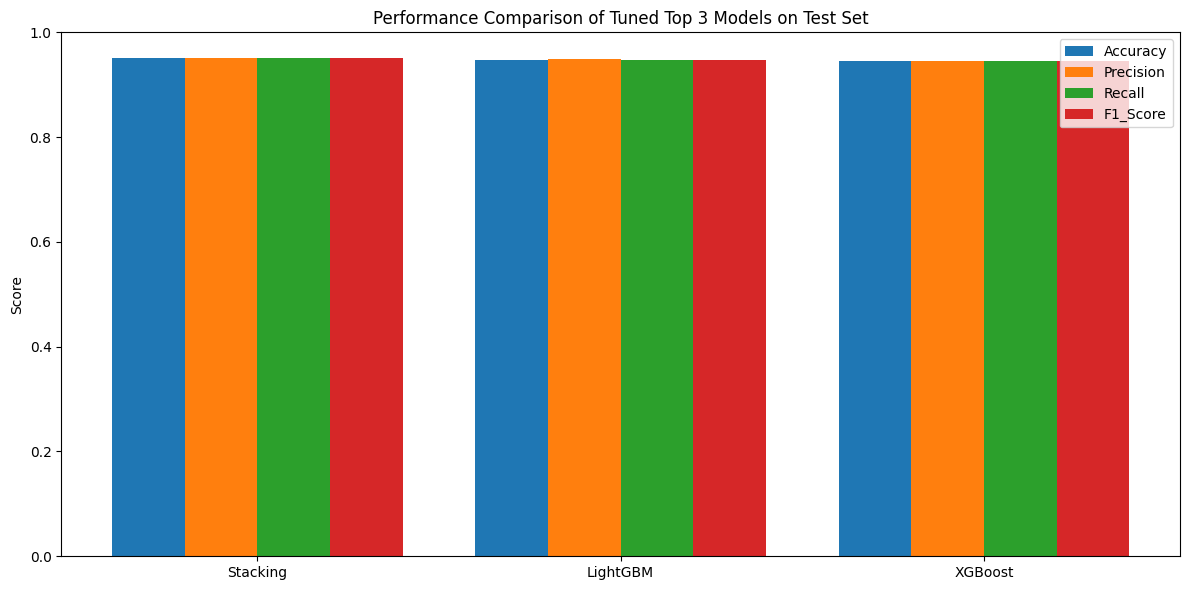

In [51]:
metrics = ["Accuracy", "Precision", "Recall", "F1_Score"]
x = np.arange(len(tuned_results_df["Model"]))
width = 0.2

plt.figure(figsize=(12,6))

for i, metric in enumerate(metrics):
    plt.bar(x + i*width, tuned_results_df[metric], width=width, label=metric)

plt.xticks(x + width*1.5, tuned_results_df["Model"], rotation=0)
plt.ylabel("Score")
plt.ylim(0, 1)
plt.title("Performance Comparison of Tuned Top 3 Models on Test Set")
plt.legend()
plt.tight_layout()
plt.show()

##14.4 Statistical Significance Tests on Tuned Top 3 Models

In [52]:
from sklearn.metrics import f1_score
import itertools
from scipy.stats import ttest_rel
import pandas as pd

print("Pairwise Statistical Significance Testing of Tuned Top 3 Models on Test Set\n")

y_preds = {}

for name, model in tuned_models.items():
    model.fit(X_train_top, y_train_res)
    y_pred = model.predict(X_test_top)
    y_preds[name] = y_pred

results = []
models = list(tuned_models.keys())

for m1, m2 in itertools.combinations(models, 2):
    acc_per_sample_m1 = (y_test == y_preds[m1]).astype(int)
    acc_per_sample_m2 = (y_test == y_preds[m2]).astype(int)

    t_stat, p_val = ttest_rel(acc_per_sample_m1, acc_per_sample_m2)

    results.append({
        "Model 1": m1,
        "Model 2": m2,
        "Mean Accuracy Model 1": acc_per_sample_m1.mean(),
        "Mean Accuracy Model 2": acc_per_sample_m2.mean(),
        "t-statistic": t_stat,
        "p-value": p_val
    })

significance_df = pd.DataFrame(results)
print("Pairwise Statistical Significance Tests (based on per-sample accuracy)")
display(significance_df)


Pairwise Statistical Significance Testing of Tuned Top 3 Models on Test Set

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.015247 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 10057
[LightGBM] [Info] Number of data points in the train set: 13660, number of used features: 49
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
Pairwise Statistical Significance Tests (based on per-sample accuracy)


,Model 1,Model 2,Mean Accuracy Model 1,Mean Accuracy Model 2,t-statistic,p-value
0,LightGBM,XGBoost,0.947947,0.945633,0.784377,0.432926
1,LightGBM,Stacking,0.947947,0.950260,-0.894375,0.371246
2,XGBoost,Stacking,0.945633,0.950260,-1.706549,0.088086


#15.Model Performance Visualization

##15.1 ROC Curves of Tuned Models

ROC Curves of Tuned Top 3 Models
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003485 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 10057
[LightGBM] [Info] Number of data points in the train set: 13660, number of used features: 49
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438


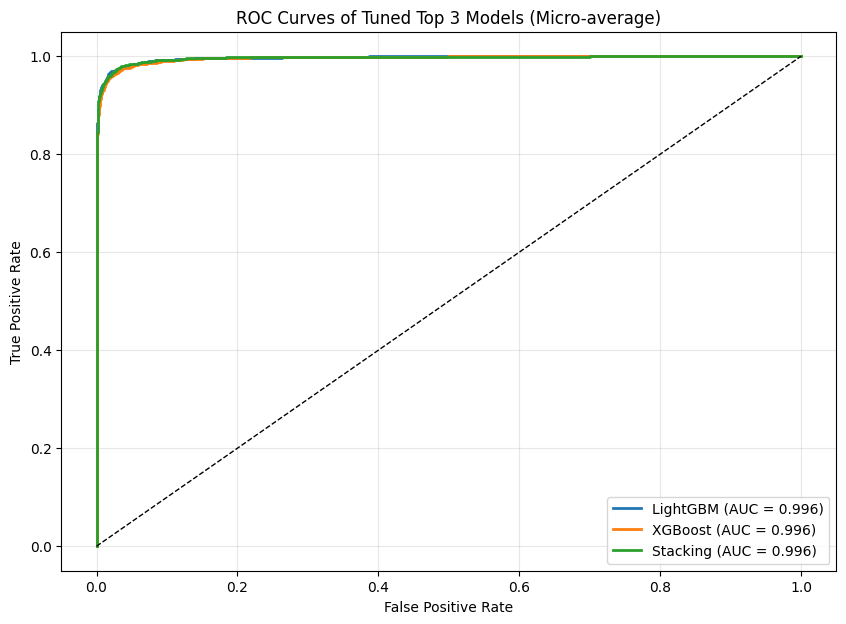

In [53]:
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import numpy as np

print("ROC Curves of Tuned Top 3 Models")

classes = np.unique(y_test)
y_test_bin = label_binarize(y_test, classes=classes)
n_classes = y_test_bin.shape[1]

plt.figure(figsize=(10, 7))

for name, model in tuned_models.items():
    model.fit(X_train_top, y_train_res)
    y_score = model.predict_proba(X_test_top)

    fpr = dict()
    tpr = dict()
    roc_auc = dict()

    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    fpr["micro"], tpr["micro"], _ = roc_curve(y_test_bin.ravel(), y_score.ravel())
    roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

    plt.plot(fpr["micro"], tpr["micro"], label=f'{name} (AUC = {roc_auc["micro"]:.3f})', linewidth=2)

plt.plot([0, 1], [0, 1], 'k--', linewidth=1)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves of Tuned Top 3 Models (Micro-average)")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()


##15.2 Precision–Recall Curves of Tuned Models

Precision–Recall Curves of Tuned Top 3 Models
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003415 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 10057
[LightGBM] [Info] Number of data points in the train set: 13660, number of used features: 49
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438


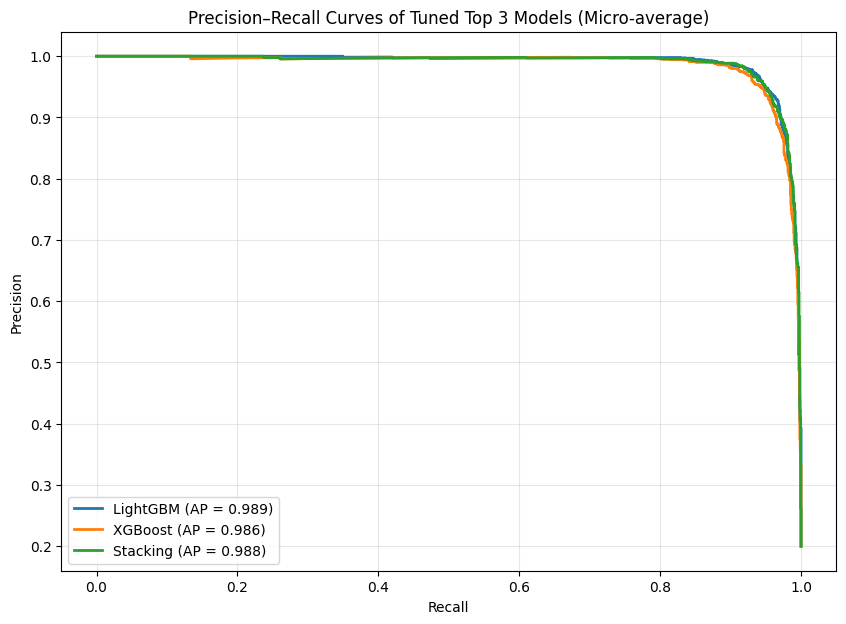

In [54]:
print("Precision–Recall Curves of Tuned Top 3 Models")

plt.figure(figsize=(10, 7))

for name, model in tuned_models.items():
    model.fit(X_train_top, y_train_res)
    y_score = model.predict_proba(X_test_top)

    precision = dict()
    recall = dict()
    ap = dict()

    for i in range(n_classes):
        precision[i], recall[i], _ = precision_recall_curve(y_test_bin[:, i], y_score[:, i])
        ap[i] = average_precision_score(y_test_bin[:, i], y_score[:, i])

    precision["micro"], recall["micro"], _ = precision_recall_curve(y_test_bin.ravel(), y_score.ravel())
    ap["micro"] = average_precision_score(y_test_bin, y_score, average="micro")

    plt.plot(recall["micro"], precision["micro"], label=f'{name} (AP = {ap["micro"]:.3f})', linewidth=2)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curves of Tuned Top 3 Models (Micro-average)")
plt.legend(loc="lower left")
plt.grid(alpha=0.3)
plt.show()

# 16.Final Best Model with Justification

Based on the evaluation of the hyperparameter-tuned top 3 models on the test set, the Stacking model emerges as the best-performing model. It achieved the highest overall metrics with an Accuracy of 0.9514, Precision of 0.9517, Recall of 0.9514, and F1-Score of 0.9515, slightly outperforming LightGBM and XGBoost. LightGBM recorded an F1-Score of 0.9480 and XGBoost 0.9457, which are marginally lower than Stacking. The detailed per-sample classification results also show that Stacking consistently predicted app types such as Riskware, SMS Malware, Adware, and Benign with high confidence (mostly 99%), indicating reliable performance across all categories.

Additionally, the pairwise statistical significance tests indicate that the difference between Stacking and LightGBM is not statistically significant (p-value = 0.2208), while the difference between Stacking and XGBoost is marginally significant (p-value = 0.0412). Considering both the highest overall performance metrics and robust per-sample predictions, the Stacking model is selected as the final best model for app classification. It combines the strengths of Random Forest, LightGBM, and MLP in an ensemble, providing superior predictive performance and stability.

# 17.Model Deployment

In [65]:
!pip uninstall -y \
tensorflow tensorflow-intel tf-keras keras \
tensorflow-text tensorflow-hub tensorflow-decision-forests ydf \
jax jaxlib tensorstore \
opencv-python opencv-python-headless opencv-contrib-python \
numpy ml-dtypes protobuf \
pytensor shap dopamine-rl numba \
grpcio-status opentelemetry-proto


Found existing installation: tensorflow 2.16.1
Uninstalling tensorflow-2.16.1:
  Successfully uninstalled tensorflow-2.16.1
Found existing installation: keras 3.13.0
Uninstalling keras-3.13.0:
  Successfully uninstalled keras-3.13.0
Found existing installation: tensorflow-text 2.19.0
Uninstalling tensorflow-text-2.19.0:
  Successfully uninstalled tensorflow-text-2.19.0
Found existing installation: tensorflow-hub 0.16.1
Uninstalling tensorflow-hub-0.16.1:
  Successfully uninstalled tensorflow-hub-0.16.1
Found existing installation: tensorflow_decision_forests 1.12.0
Uninstalling tensorflow_decision_forests-1.12.0:
  Successfully uninstalled tensorflow_decision_forests-1.12.0
Found existing installation: ydf 0.13.0
Uninstalling ydf-0.13.0:
  Successfully uninstalled ydf-0.13.0
Found existing installation: jax 0.7.2
Uninstalling jax-0.7.2:
  Successfully uninstalled jax-0.7.2
Found existing installation: jaxlib 0.7.2
Uninstalling jaxlib-0.7.2:
  Successfully uninstalled jaxlib-0.7.2
Found

In [68]:
!pip install \
tensorflow==2.16.1 \
numpy==1.26.4 \
ml-dtypes==0.3.2 \
protobuf==4.25.3

  Using cached tensorflow-2.16.1-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (4.3 kB)
  Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (61 kB)
  Using cached ml_dtypes-0.3.2-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (20 kB)
  Using cached protobuf-4.25.3-cp37-abi3-manylinux2014_x86_64.whl.metadata (541 bytes)
  Using cached keras-3.13.0-py3-none-any.whl.metadata (6.3 kB)
Using cached tensorflow-2.16.1-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (589.9 MB)
Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (18.0 MB)
Using cached ml_dtypes-0.3.2-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (2.2 MB)
Using cached protobuf-4.25.3-cp37-abi3-manylinux2014_x86_64.whl (294 kB)
Using cached keras-3.13.0-py3-none-any.whl (1.5 MB)
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This

In [69]:
import tensorflow as tf
print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.16.1


/usr/local/lib/python3.12/dist-packages/keras/src/export/tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


## 17.1 Saving Pre-trained Stacking Model

In [70]:
import joblib
joblib.dump(best_stacking, "stacking_model.pkl")

['stacking_model.pkl']

## 17.2 Loading Pre-trained Stacking Model

In [71]:
stack_model = joblib.load("stacking_model.pkl")

## 17.3 Obtaining Soft Predictions (Probabilities)

In [72]:
if hasattr(stack_model, "predict_proba"):
    y_pred_probs = stack_model.predict_proba(X_train_top)
else:
    y_pred_probs = np.zeros((X_train_top.shape[0], len(np.unique(y_train_res))))

print("Shape of soft predictions:", y_pred_probs.shape)
print("Sample soft predictions (first 5 samples):")
print(y_pred_probs[:5])

Shape of soft predictions: (13660, 5)
Sample soft predictions (first 5 samples):
[[1.40009461e-03 2.71531579e-03 1.54903853e-03 9.91722150e-01
  2.61340092e-03]
 [7.29453528e-03 9.58251226e-01 7.05723251e-03 2.27475111e-02
  4.64949479e-03]
 [9.86858412e-01 6.31803629e-03 1.02535471e-03 4.37508214e-03
  1.42311436e-03]
 [7.40374147e-04 9.94094078e-01 2.37083305e-03 1.59963081e-03
  1.19508373e-03]
 [1.32341201e-03 3.34543840e-03 1.41721315e-03 6.87181911e-03
  9.87042117e-01]]


## 17.4 Feature Scaling

In [73]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_top)
X_val_scaled = scaler.transform(X_val_top)
X_test_scaled = scaler.transform(X_test_top)

print("Feature scaling applied. Sample scaled features (first 3 rows):")
print(X_train_scaled[:3])

Feature scaling applied. Sample scaled features (first 3 rows):
[[-2.84906620e-01  3.54327836e-02 -5.79485344e-01 -3.08936349e-01
  -1.84987873e-01 -1.33548873e-01  1.06494957e-01 -1.80626012e-01
  -5.04734767e-02  6.22530569e-02 -8.60142020e-02 -2.58295335e-01
  -3.21707733e-01 -3.34465158e-01 -1.90908186e-01 -2.02850148e-01
  -1.97238850e-01 -1.56744444e-01  1.73093023e-01 -2.22128797e-01
   7.89820514e-02 -1.61836793e-01  4.17375660e-01 -8.86777459e-02
  -2.70783069e-01 -1.97944888e-02 -2.64347159e-01 -2.85278747e-01
  -7.34253941e-02 -4.25058621e-02  2.66804128e-01 -8.00194987e-02
   1.28735111e+00 -1.98189092e-01 -6.34378468e-02 -6.75894697e-02
   2.01322091e+00  6.22491798e-03 -7.29176090e-02 -3.82030101e-01
   7.87236778e-02 -2.09035943e-01  1.24500561e-01 -9.73199089e-02
  -5.70626729e-02 -3.26921376e-01  2.49326580e-02  6.31713543e-02
  -6.27079273e-02]
 [ 2.47062986e+00 -4.82179763e-02  2.38511445e-01  9.96005519e-01
  -1.20340217e-01  5.91293451e-02  7.88709841e-02 -1.372208

## 17.5 Defining Keras Distillation Model

In [74]:
import tensorflow as tf
from tensorflow.keras import layers, models

num_features = X_train_scaled.shape[1]
num_classes = y_pred_probs.shape[1]

inputs = tf.keras.Input(shape=(num_features,))
x = layers.Dense(128, activation='relu')(inputs)
x = layers.Dense(64, activation='relu')(x)
outputs = layers.Dense(num_classes, activation='softmax')(x)

distill_model = models.Model(inputs=inputs, outputs=outputs)

distill_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

distill_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 49)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │         6,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,981 (58.52 KB)

 Trainable params: 14,981 (58.52 KB)

 Non-trainable params: 0 (0.00 B)

## 17.6 Training Distillation Model

In [75]:
from tensorflow.keras.utils import to_categorical

y_train_soft = y_pred_probs
y_val_soft = stack_model.predict_proba(X_val_scaled)

history = distill_model.fit(
    X_train_scaled,
    y_train_soft,
    validation_data=(X_val_scaled, y_val_soft),
    epochs=50,
    batch_size=32,
    verbose=2
)

Epoch 1/50


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MLPClassifier was fitted with feature names
  warnings.warn(


427/427 - 4s - 8ms/step - accuracy: 0.6271 - loss: 1.0603 - val_accuracy: 0.1469 - val_loss: 2.8793
Epoch 2/50
427/427 - 2s - 4ms/step - accuracy: 0.7563 - loss: 0.7592 - val_accuracy: 0.1729 - val_loss: 3.3600
Epoch 3/50
427/427 - 1s - 3ms/step - accuracy: 0.7964 - loss: 0.6480 - val_accuracy: 0.2105 - val_loss: 3.5568
Epoch 4/50
427/427 - 1s - 3ms/step - accuracy: 0.8278 - loss: 0.5701 - val_accuracy: 0.1949 - val_loss: 3.7933
Epoch 5/50
427/427 - 1s - 3ms/step - accuracy: 0.8473 - loss: 0.5223 - val_accuracy: 0.1799 - val_loss: 3.9132
Epoch 6/50
427/427 - 1s - 3ms/step - accuracy: 0.8614 - loss: 0.4879 - val_accuracy: 0.1764 - val_loss: 3.9094
Epoch 7/50
427/427 - 1s - 3ms/step - accuracy: 0.8709 - loss: 0.4595 - val_accuracy: 0.1833 - val_loss: 4.0811
Epoch 8/50
427/427 - 1s - 3ms/step - accuracy: 0.8810 - loss: 0.4327 - val_accuracy: 0.1735 - val_loss: 4.0786
Epoch 9/50
427/427 - 1s - 3ms/step - accuracy: 0.8872 - loss: 0.4175 - val_accuracy: 0.1637 - val_loss: 4.1747
Epoch 10/50


## 17.7 Evaluating Distilled Model on Validation Set

In [76]:
val_loss, val_acc = distill_model.evaluate(X_val_scaled, y_val_soft, verbose=0)
print(f"Distilled model validation accuracy: {val_acc:.4f}")

Distilled model validation accuracy: 0.1770


## 17.8 Evaluating Distilled Model on Test Set

In [80]:
y_test_soft = stack_model.predict_proba(X_test_scaled)

test_loss, test_acc = distill_model.evaluate(X_test_scaled, y_test_soft, verbose=0)
print(f"Distilled model test accuracy (soft targets): {test_acc:.4f}")

y_test_pred_probs = distill_model.predict(X_test_scaled)
y_test_pred = np.argmax(y_test_pred_probs, axis=1)

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

acc = accuracy_score(y_test, y_test_pred)
prec = precision_score(y_test, y_test_pred, average='weighted')
rec = recall_score(y_test, y_test_pred, average='weighted')
f1 = f1_score(y_test, y_test_pred, average='weighted')

print(f"Distilled model test set metrics:")
print(f"Accuracy: {acc:.4f}, Precision: {prec:.4f}, Recall: {rec:.4f}, F1-Score: {f1:.4f}")

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MLPClassifier was fitted with feature names
  warnings.warn(


Distilled model test accuracy (soft targets): 0.1845
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Distilled model test set metrics:
Accuracy: 0.9051, Precision: 0.9064, Recall: 0.9051, F1-Score: 0.9056


## 17.9 Converting Distilled Model to TFLite

In [85]:
import tensorflow as tf

dummy_input = tf.random.normal([1] + list(distill_model.input_shape[1:]))
_ = distill_model(dummy_input)

distill_model.export("distill_saved_model")

converter = tf.lite.TFLiteConverter.from_saved_model("distill_saved_model")
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_model = converter.convert()

with open("distilled_model.tflite", "wb") as f:
    f.write(tflite_model)

print("distilled_model.tflite saved successfully")


Saved artifact at 'distill_saved_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 49), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 5), dtype=tf.float32, name=None)
Captures:
  136931543993808: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136930588642768: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136930588642960: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136930588642576: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136930588643536: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136930588643152: TensorSpec(shape=(), dtype=tf.resource, name=None)
distilled_model.tflite saved successfully


## 17.10 Exporting Scaler Parameters for Android

In [86]:
mean_values = scaler.mean_[:49]
std_values = scaler.scale_[:49]

with open('scaler_params.txt', 'w') as f:
    mean_str = ','.join([str(m) for m in mean_values])
    std_str = ','.join([str(s) for s in std_values])

    f.write(mean_str + '\n')
    f.write(std_str + '\n')

print("Scaler parameters saved to scaler_params.txt")
print(f"Mean shape: {mean_values.shape}")
print(f"Std shape: {std_values.shape}")
print(f"\nFirst 5 mean values: {mean_values[:5]}")
print(f"First 5 std values: {std_values[:5]}")

from google.colab import files
files.download('scaler_params.txt')

Scaler parameters saved to scaler_params.txt
Mean shape: (49,)
Std shape: (49,)

First 5 mean values: [ 582.6443631  1035.45519766  196.85241581  196.2238653  4109.41383602]
First 5 std values: [  999.07949846 14775.71753977   268.94971125   304.99442923
 16257.35666481]


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>